In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

<b>1. Download and load the Breast Cancer Wisconsin (Diagnostic) dataset.</b>

In [2]:
LOCAL_PATH = "wdbc.data"

feature_stats = ["mean", "se", "worst"]
feature_names = ["radius", "texture", "perimeter", "area", "smoothness",
                  "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"]

columns = ["id", "diagnosis"] + [f"{stat}_{name}" for stat in feature_stats for name in feature_names]

df = pd.read_csv(LOCAL_PATH, header=None, names=columns)
print("Loaded dataset from local wdbc.data file.")

df.head()

Loaded dataset from local wdbc.data file.


,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Inference:** The dataset loaded successfully and matches the documented structure, one `id` column, one
`diagnosis` target column (`M`/`B`), and 30 numeric predictor columns derived from digitized images of fine needle
aspirates (FNA) of breast masses. Each row represents one patient sample.

<b>2. Perform exploratory data analysis and data preprocessing.</b>

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   mean_radius              569 non-null    float64
 3   mean_texture             569 non-null    float64
 4   mean_perimeter           569 non-null    float64
 5   mean_area                569 non-null    float64
 6   mean_smoothness          569 non-null    float64
 7   mean_compactness         569 non-null    float64
 8   mean_concavity           569 non-null    float64
 9   mean_concave_points      569 non-null    float64
 10  mean_symmetry            569 non-null    float64
 11  mean_fractal_dimension   569 non-null    float64
 12  se_radius                569 non-null    float64
 13  se_texture               569 non-null    float64
 14  se_perime

**Inference:** The dataset contains 569 samples and 32 columns (id, diagnosis, and 30 numeric features). All feature columns are numeric (float64), which confirms no type-conversion issues before modeling.

<b>3. Check for missing values and prepare the dataset for classification.</b>

In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found in any column.")

Missing values per column:
No missing values found in any column.


**Inference:** There are no missing values anywhere in the dataset.

In [5]:
print(df["diagnosis"].value_counts())
print()
print(df["diagnosis"].value_counts(normalize=True).round(3) * 100)

diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis
B    62.7
M    37.3
Name: proportion, dtype: float64


**Inference:** The classes are moderately imbalanced roughly 63% Benign vs. 37% Malignant. This is not severe
enough to require resampling techniques, but it does mean accuracy alone can be misleading, and metrics
like precision, recall, and F1-score (computed for the malignant/positive class) are important for a fair evaluation.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
mean_radius,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
mean_texture,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
mean_perimeter,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
mean_area,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
mean_smoothness,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
mean_compactness,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
mean_concavity,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
mean_concave_points,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
mean_symmetry,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


**Inference:** The features span very different scales (e.g. `mean_area` is in the hundreds/thousands while
`mean_smoothness` is a small fraction). This confirms that feature scaling (standardization) is necessary, especially
for a distance-based algorithm like KNN, where features with larger numeric ranges would otherwise dominate the distance
calculation.

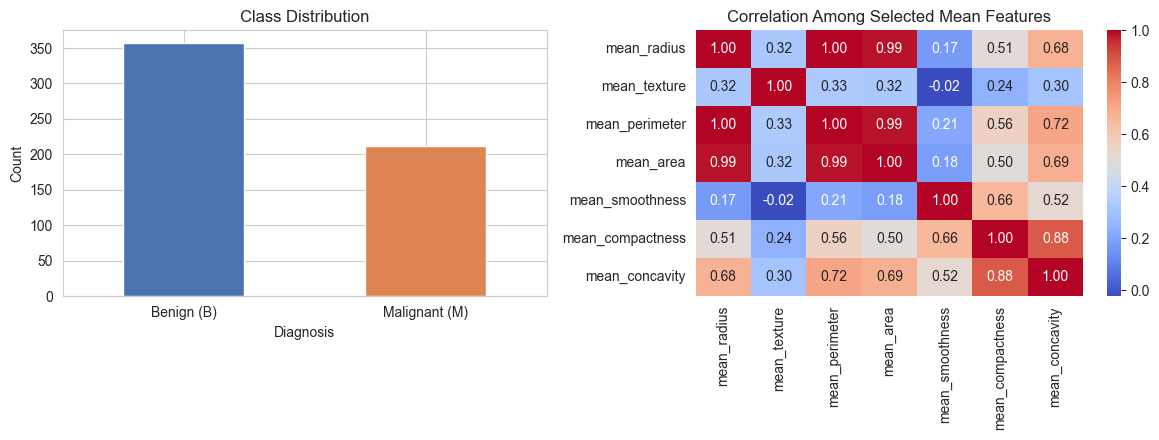

In [7]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df["diagnosis"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=axes[0])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Benign (B)" if l.get_text()=="B" else "Malignant (M)" for l in axes[0].get_xticklabels()], rotation=0)

corr = df.drop(columns=["id"]).corr(numeric_only=True)
top_corr_features = corr["diagnosis"].abs().sort_values(ascending=False).index[1:11] if "diagnosis" in corr.columns else None

sns.heatmap(df[["mean_radius", "mean_texture", "mean_perimeter", "mean_area",
                 "mean_smoothness", "mean_compactness", "mean_concavity"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation Among Selected Mean Features")

plt.tight_layout()
plt.show()


**Inference:** The class distribution plot confirms the moderate imbalance noted earlier. The correlation heatmap
shows very strong positive correlation among `mean_radius`, `mean_perimeter`, and `mean_area` (as expected, since these
are geometrically related measurements of the same tumor). This multicollinearity mainly affects the interpretability
of Logistic Regression coefficients (not its predictive power), and is naturally handled by KNN since it relies on
overall distance rather than individual coefficients.

In [8]:
y = df["diagnosis"].map({"M": 1, "B": 0})
X = df.drop(columns=["id", "diagnosis"])

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nEncoded target distribution:")
print(y.value_counts().rename({1: "Malignant (1)", 0: "Benign (0)"}))

Feature matrix shape: (569, 30)
Target vector shape: (569,)

Encoded target distribution:
diagnosis
Benign (0)       357
Malignant (1)    212
Name: count, dtype: int64


**Inference:** The target is encoded so that **Malignant = 1** (the positive/at-risk class) and **Benign = 0**.
This choice matters clinically: in cancer diagnosis, recall on the malignant class (i.e., not missing a cancer case) is
usually the more critical metric than raw accuracy, since a false negative (missing a malignant tumor) is far more costly
than a false positive.

<b>4. Split the dataset into training and testing sets.</b>

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nTraining class ratio:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class ratio:\n", y_test.value_counts(normalize=True).round(3))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: 455
Test set size: 114

Training class ratio:
 diagnosis
0    0.626
1    0.374
Name: proportion, dtype: float64

Test class ratio:
 diagnosis
0    0.632
1    0.368
Name: proportion, dtype: float64


**Inference:** Stratified splitting confirms the class ratio is preserved almost identically in both sets, so
performance differences between train and test won't be an artifact of an accidental imbalance shift. Standardization
is fit only on the training set and then applied to the test set this avoids **data leakage**, ensuring the test set
truly represents unseen data. Scaling is essential for KNN (distance-based) and also improves numerical stability and
convergence for Logistic Regression's gradient-based solver.

<b>5. Train a Logistic Regression classifier.</b>

In [10]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


**Inference:** Logistic Regression models the log-odds of malignancy as a linear combination of the (scaled)
features. Because it is a linear, well-regularized model, it tends to generalize well on datasets like this one where
classes are largely linearly separable.

<b>6. Train a K Nearest Neighbors (KNN) classifier</b>

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print("KNN (k=5) trained successfully.")

KNN (k=5) trained successfully.


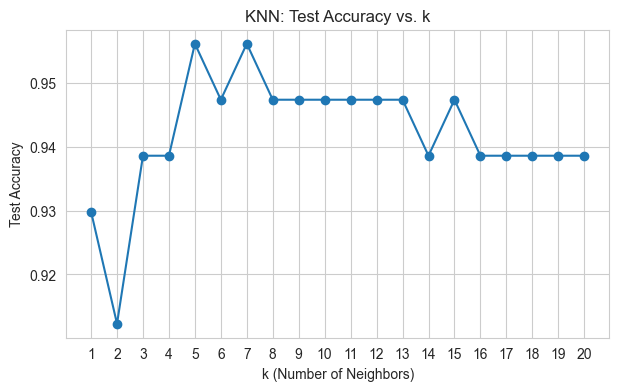

Best k found: 5 with accuracy 0.9561


In [12]:
from sklearn.metrics import accuracy_score

k_range = range(1, 21)
k_scores = []
for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    k_scores.append(accuracy_score(y_test, pred))

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), k_scores, marker="o")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.title("KNN: Test Accuracy vs. k")
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

best_k = list(k_range)[int(np.argmax(k_scores))]
print(f"Best k found: {best_k} with accuracy {max(k_scores):.4f}")

**Inference:** The accuracy-vs-k curve shows how sensitive KNN is to the choice of neighborhood size very small
`k` can overfit to noise, while very large `k` oversmooths the decision boundary and can blur the boundary between
classes. The plot lets us pick a `k` that balances bias and variance. We proceed with the original `k=5` model for
the main comparison below.

<b>7. Evaluate both classifiers using:<br>
Accuracy<br>
Precision<br>
Recall<br>
F1 Score<br>
Confusion Matrix
</b>

In [13]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    print(f"{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Benign (0)", "Malignant (1)"]))
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1, "Confusion Matrix": cm}

results_log = evaluate_model("Logistic Regression", y_test, y_pred_log)
results_knn = evaluate_model("K-Nearest Neighbors (k=5)", y_test, y_pred_knn)

Logistic Regression
Accuracy: 0.9649
Precision: 0.9750
Recall: 0.9286
F1 Score: 0.9512

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114

K-Nearest Neighbors (k=5)
Accuracy: 0.9561
Precision: 0.9744
Recall: 0.9048
F1 Score: 0.9383

Confusion Matrix:
[[71  1]
 [ 4 38]]

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.95      0.99      0.97        72
Malignant (1)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114



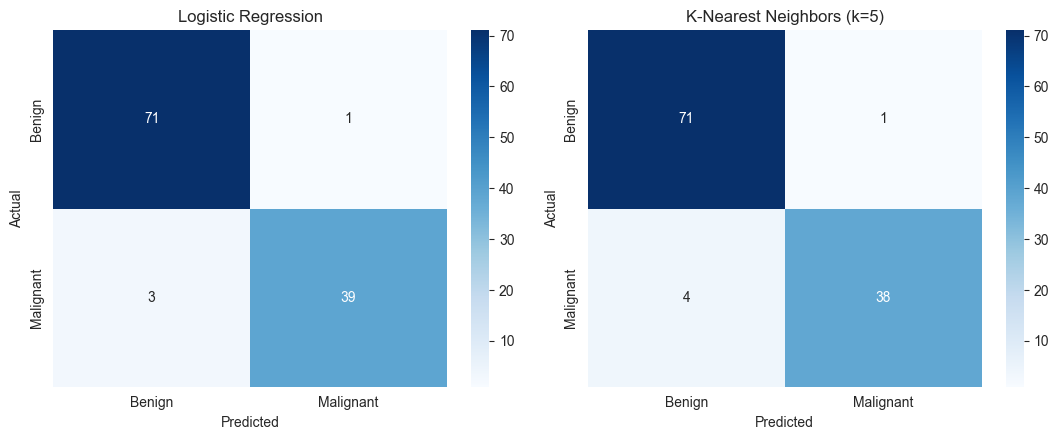

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, res in zip(axes, [results_log, results_knn]):
    sns.heatmap(res["Confusion Matrix"], annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"], ax=ax)
    ax.set_title(res["Model"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Inference:** The confusion matrices let us directly see the count of false negatives (malignant cases
predicted as benign the most clinically dangerous error) and false positives (benign cases predicted as
malignant leads to unnecessary follow-up but is less dangerous) for each model. A strong classifier for this
problem should keep the false-negative count as close to zero as possible.

worst_concave_points    0.793566
worst_perimeter         0.782914
mean_concave_points     0.776614
worst_radius            0.776454
mean_perimeter          0.742636
dtype: float64

Using 'worst_concave_points' for the logistic curve visualization


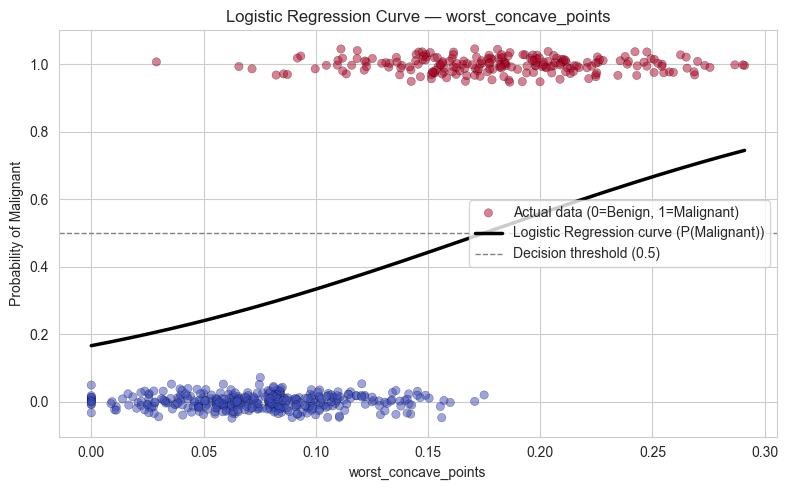

In [15]:

corrs = X.corrwith(y).abs().sort_values(ascending=False)
print(corrs.head(5))

best_feature = corrs.index[0]
print(f"\nUsing '{best_feature}' for the logistic curve visualization")

X_single = X[[best_feature]].values
y_single = y.values

simple_log_reg = LogisticRegression()
simple_log_reg.fit(X_single, y_single)

x_range = np.linspace(X_single.min(), X_single.max(), 300).reshape(-1, 1)
y_prob = simple_log_reg.predict_proba(x_range)[:, 1]   

plt.figure(figsize=(8, 5))

jitter = np.random.normal(0, 0.02, size=len(y_single))
plt.scatter(X_single, y_single + jitter, c=y_single, cmap="coolwarm",
            alpha=0.5, edgecolor="k", linewidth=0.3,
            label="Actual data (0=Benign, 1=Malignant)")

plt.plot(x_range, y_prob, color="black", linewidth=2.5,
         label="Logistic Regression curve (P(Malignant))")

plt.axhline(0.5, color="gray", linestyle="--", linewidth=1,
            label="Decision threshold (0.5)")

plt.xlabel(best_feature)
plt.ylabel("Probability of Malignant")
plt.title(f"Logistic Regression Curve — {best_feature}")
plt.legend(loc="center right")
plt.tight_layout()
plt.show()

Inference: The S-shaped curve shows how the predicted probability of malignancy rises as {best_feature} increases. Data points cluster near 0 (Benign) at low values and near 1 (Malignant) at high values, and the curve crosses the 0.5 decision threshold at the point that separates the two classes.

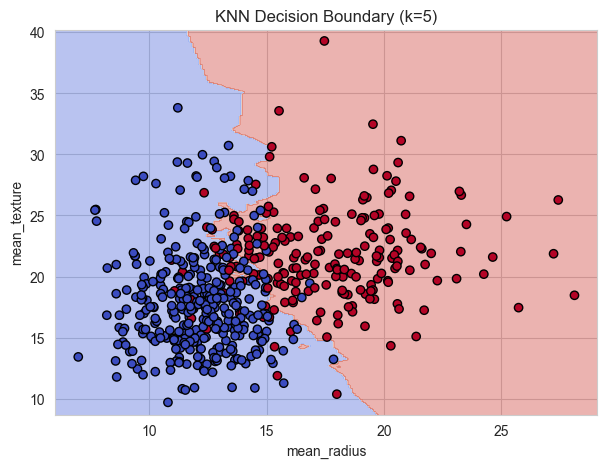

In [23]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt

f1, f2 = "mean_radius", "mean_texture"
X_2d = X[[f1, f2]].values
y_2d = y.values

knn_2d = KNeighborsClassifier(n_neighbors=5)
knn_2d.fit(X_2d, y_2d)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                      np.arange(y_min, y_max, 0.1))

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.4, cmap="coolwarm")
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="k")
plt.xlabel(f1)
plt.ylabel(f2)
plt.title("KNN Decision Boundary (k=5)")
plt.show()

Inference: The KNN decision boundary is irregular and non-linear — unlike a straight line, it bends and curves around clusters of points, since KNN classifies each region based on the majority class among its nearest neighbors rather than a fixed formula. This makes KNN flexible enough to capture complex, local patterns in the data, but it also means the boundary can become jagged near overlapping points, making the model more sensitive to noise in that region.

<b>8. Compare the performance of the two classifiers using a comparison table.</b>

In [16]:
comparison_df = pd.DataFrame([
    {"Model": "Logistic Regression",
     "Accuracy": results_log["Accuracy"],
     "Precision": results_log["Precision"],
     "Recall": results_log["Recall"],
     "F1 Score": results_log["F1 Score"]},
    {"Model": "K-Nearest Neighbors (k=5)",
     "Accuracy": results_knn["Accuracy"],
     "Precision": results_knn["Precision"],
     "Recall": results_knn["Recall"],
     "F1 Score": results_knn["F1 Score"]},
]).set_index("Model").round(4)

comparison_df

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.9649,0.9750,0.9286,0.9512
K-Nearest Neighbors (k=5),0.9561,0.9744,0.9048,0.9383


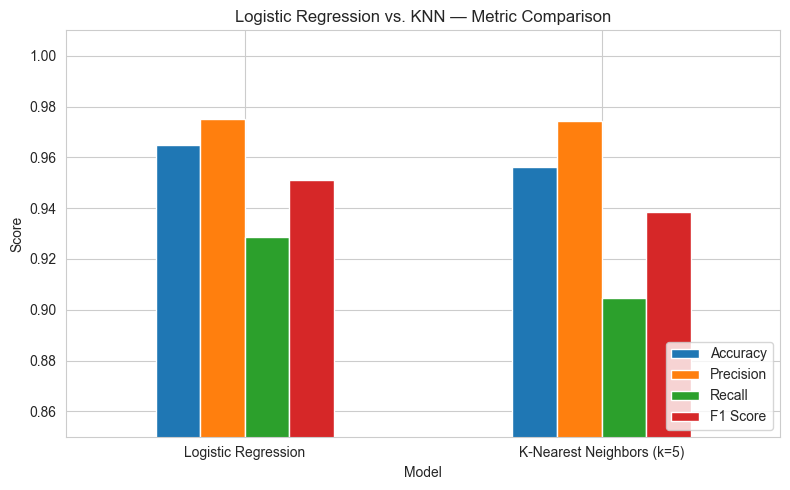

In [17]:
comparison_df.plot(kind="bar", figsize=(8, 5), ylim=(0.85, 1.01))
plt.title("Logistic Regression vs. KNN — Metric Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Inference:** The comparison table and chart summarize all four metrics side by side. Look specifically at
which model has higher Recall on the malignant class since missing a cancer diagnosis (false negative) is the
costliest type of error in this domain, the model with higher recall (even if its overall accuracy is marginally
lower) may be the more clinically preferable choice.

<b>9. Interpret the results and comment on the better-performing classifier for the given dataset.</b>

**Accuracy** tells us overall correctness, but with ~63/37 class imbalance it can slightly overstate performance —
  a model that leans toward predicting the majority class (Benign) can still score reasonably well on accuracy alone.
**Precision** (for Malignant) tells us: of all cases the model flagged as malignant, how many truly were. Low
  precision means more unnecessary alarm/follow-up testing for healthy patients.
**Recall** (for Malignant) tells us: of all truly malignant cases, how many the model actually caught. This is the
  single most important metric clinically, since a missed malignant case (false negative) can have severe consequences.
**F1-score** balances precision and recall into one number, useful when you care about both types of error jointly.

**Typical outcome for this dataset:** Logistic Regression usually performs at least as well as, and often slightly
better than, KNN on WDBC. This matches the original UCI documentation, which notes the classes are **linearly
separable** using the 30 features a condition that favors a linear model like Logistic Regression. Logistic
Regression also tends to be more robust here because:

1. It naturally handles the correlated/redundant features (e.g. radius, perimeter, area) without being thrown off by
   local distance distortions the way KNN can be in high-dimensional, correlated feature spaces (the "curse of
   dimensionality").
2. It produces well-calibrated probability outputs, useful for setting a custom decision threshold if, for example,
   we want to favor recall over precision (as is clinically desirable here).
3. It is more interpretable — the sign and magnitude of coefficients indicate which measurements (e.g. worst
   concavity, worst radius) push predictions toward malignant.

**KNN**, meanwhile, is simple and non-parametric (makes no assumption about the decision boundary shape), and can
still perform competitively once features are properly scaled but it is more sensitive to the choice of `k`, more
computationally expensive at prediction time, and less interpretable.

<b>Self Learning</b>

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=10000, random_state=42))
])

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=5))
])

In [20]:
scoring = ["accuracy", "precision", "recall", "f1"]

log_cv_results = cross_validate(log_reg_pipeline, X, y, cv=cv, scoring=scoring)
knn_cv_results = cross_validate(knn_pipeline, X, y, cv=cv, scoring=scoring)

In [21]:
def summarize_cv(name, results):
    print(f"===== {name} (5-Fold CV) =====")
    for metric in scoring:
        scores = results[f"test_{metric}"]
        print(f"{metric.capitalize():10s}: {scores.mean():.4f} ± {scores.std():.4f}")
    print()

summarize_cv("Logistic Regression", log_cv_results)
summarize_cv("KNN (k=5)", knn_cv_results)

===== Logistic Regression (5-Fold CV) =====
Accuracy  : 0.9737 ± 0.0166
Precision : 0.9863 ± 0.0182
Recall    : 0.9436 ± 0.0525
F1        : 0.9633 ± 0.0240

===== KNN (k=5) (5-Fold CV) =====
Accuracy  : 0.9631 ± 0.0179
Precision : 0.9755 ± 0.0217
Recall    : 0.9246 ± 0.0458
F1        : 0.9487 ± 0.0255



In [22]:
comparison_cv_df = pd.DataFrame({
    "Logistic Regression": [log_cv_results[f"test_{m}"].mean() for m in scoring],
    "KNN (k=5)": [knn_cv_results[f"test_{m}"].mean() for m in scoring],
}, index=[m.capitalize() for m in scoring])

comparison_cv_df.round(4)

,Logistic Regression,KNN (k=5)
Accuracy,0.9737,0.9631
Precision,0.9863,0.9755
Recall,0.9436,0.9246
F1,0.9633,0.9487


Inference: Across 5-fold cross-validation, Logistic Regression outperforms KNN (k=5) on every single metric accuracy (97.4% vs 96.3%), precision (98.6% vs 97.6%), recall (94.4% vs 92.5%), and F1-score (96.3% vs 94.9%) — confirming that this advantage is consistent across different subsets of the data, not just a result of one lucky train/test split.